<a href="https://colab.research.google.com/github/Madhuri951-code/Bankruptcy_EDA_Project/blob/main/IDP_Linear_Regression_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>






# **STUDENT ATTENDANCE PERCENTAGE PREDICTION USING LINEAR REGRESSION**

# **STEP 1: Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**Machine Learning libraries:**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# **STEP 2: Load the Dataset**

In [ ]:
df = pd.read_csv("/content/student_attendance_percentage_missing_values_dataset (1).csv")
df.head()


,student_id,gender,course,year,hostel_resident,internet_access,study_hours_per_day,sleep_hours_per_day,previous_attendance_percentage,classes_conducted,classes_attended,attendance_percentage
0,1,Male,EEE,2,Yes,No,5.0,6.0,89.0,131,116,88.55
1,2,Female,NaN,1,No,Yes,NaN,NaN,NaN,144,93,64.58
2,3,Male,NaN,4,No,No,3.0,7.0,75.0,117,87,74.36
3,4,Male,EEE,3,Yes,No,6.0,7.0,92.0,146,134,91.78
4,5,Male,NaN,1,No,Yes,4.0,6.0,92.0,121,111,91.74


**Check structure:**

In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   student_id                      5000 non-null   int64  
 1   gender                          4600 non-null   object 
 2   course                          4600 non-null   object 
 3   year                            5000 non-null   int64  
 4   hostel_resident                 5000 non-null   object 
 5   internet_access                 4600 non-null   object 
 6   study_hours_per_day             4600 non-null   float64
 7   sleep_hours_per_day             4600 non-null   float64
 8   previous_attendance_percentage  4600 non-null   float64
 9   classes_conducted               5000 non-null   int64  
 10  classes_attended                5000 non-null   int64  
 11  attendance_percentage           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)

,student_id,year,study_hours_per_day,sleep_hours_per_day,previous_attendance_percentage,classes_conducted,classes_attended,attendance_percentage
count,5000.000000,5000.000000,4600.000000,4600.000000,4600.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,2.472400,4.525435,6.035435,72.258696,114.553000,82.200000,71.842138
std,1443.520003,1.129555,2.318095,1.402420,12.982335,20.100706,20.462105,12.987677
min,1.000000,1.000000,1.000000,4.000000,50.000000,80.000000,40.000000,49.380000
25%,1250.750000,1.000000,2.000000,5.000000,61.000000,97.000000,67.000000,60.800000
50%,2500.500000,2.000000,5.000000,6.000000,72.000000,114.000000,80.000000,71.750000
75%,3750.250000,3.000000,7.000000,7.000000,84.000000,132.000000,96.000000,83.537500
max,5000.000000,4.000000,8.000000,8.000000,94.000000,149.000000,139.000000,94.000000


# **STEP 3: Handle Missing Values**

**3.1 Numerical Columns**

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].isnull().sum()


,0
student_id,0
year,0
study_hours_per_day,400
sleep_hours_per_day,400
previous_attendance_percentage,400
classes_conducted,0
classes_attended,0
attendance_percentage,0


**Fill missing values with mean:**

In [ ]:
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


**3.2 Categorical Columns**

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols].isnull().sum()


,0
gender,400
course,400
hostel_resident,0
internet_access,400


**Fill missing values with mode:**

In [ ]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipykernel_3021/3902818140.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


# **STEP 4: Convert Categorical to Numerical**

In [ ]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


**Now check:**

In [ ]:
df.head()


,student_id,year,study_hours_per_day,sleep_hours_per_day,previous_attendance_percentage,classes_conducted,classes_attended,attendance_percentage,gender_Male,course_ECE,course_EEE,course_IT,course_MECH,hostel_resident_Yes,internet_access_Yes
0,1,2,5.000000,6.000000,89.000000,131,116,88.55,True,False,True,False,False,True,False
1,2,1,4.525435,6.035435,72.258696,144,93,64.58,False,True,False,False,False,False,True
2,3,4,3.000000,7.000000,75.000000,117,87,74.36,True,True,False,False,False,False,False
3,4,3,6.000000,7.000000,92.000000,146,134,91.78,True,False,True,False,False,True,False
4,5,1,4.000000,6.000000,92.000000,121,111,91.74,True,True,False,False,False,False,True


At this stage:           
✔ No missing values                 
✔ All columns numeric                 
✔ Target still in original percentage form

# **STEP 5: Separate Features (X) and Target (y)**

In [ ]:
X = df.drop("attendance_percentage", axis=1)
y = df["attendance_percentage"]


We DO NOT scale y.

# **STEP 6: Split the Dataset**

80% Training        
20% Testing




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# **STEP 7: Scale Only Feature Variables (X)**

We scale ONLY X             
y remains original attendance percentage

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# **STEP 8: Train the Model**

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

# **STEP 9: Make Predictions**

In [ ]:
y_pred = model.predict(X_test_scaled)


# **STEP 10: Evaluate Model**

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Absolute Error: 1.3883095947078528
Mean Squared Error: 3.678403333419079
R2 Score: 0.9779386452338081


R2 closer to 1 = better model.

# **STEP 11: Create Final Output Table**

In [ ]:
results = pd.DataFrame({
    "Actual_Attendance": y_test.values,
    "Predicted_Attendance": y_pred
})

results.head()


,Actual_Attendance,Predicted_Attendance
0,50.57,54.274995
1,51.04,53.605977
2,74.81,75.180128
3,77.36,77.111866
4,90.52,90.792575


# **STEP 12: Identify Students At Risk (< 75%)**

In [ ]:
results["At_Risk"] = results["Predicted_Attendance"] < 75
results.head()


,Actual_Attendance,Predicted_Attendance,At_Risk
0,50.57,54.274995,True
1,51.04,53.605977,True
2,74.81,75.180128,False
3,77.36,77.111866,False
4,90.52,90.792575,False


# **STEP 13: Show Only At-Risk Students**

In [ ]:
at_risk_students = results[results["At_Risk"] == True]
at_risk_students


,Actual_Attendance,Predicted_Attendance,At_Risk
0,50.57,54.274995,True
1,51.04,53.605977,True
7,71.53,71.593113,True
9,57.52,57.796376,True
12,61.79,61.299999,True
...,...,...,...
992,73.53,73.005728,True
993,62.70,62.043124,True
996,69.44,69.729890,True
997,54.73,51.134930,True


# **STEP 14: Count At-Risk Students**

In [ ]:
print("Number of At-Risk Students:", at_risk_students.shape[0])


Number of At-Risk Students: 552


# **STEP 15: Visualize Risk Distribution**

# **Actual vs Predicted Attendance (Full 5000 Samples View)**

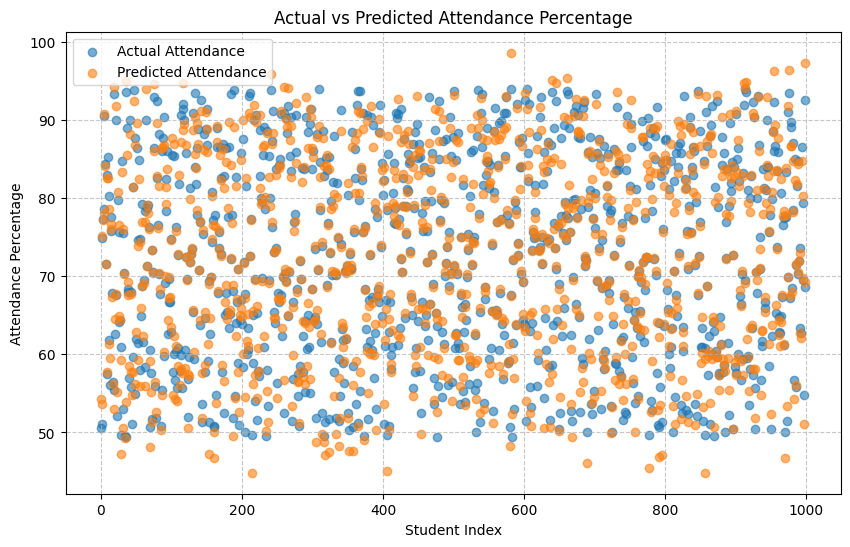

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(range(len(y_test)), y_test, label="Actual Attendance", alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted Attendance", alpha=0.6)

plt.xlabel("Student Index")
plt.ylabel("Attendance Percentage")
plt.title("Actual vs Predicted Attendance Percentage")

plt.legend(loc='upper left', fontsize='medium')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Explanation:

X-axis → Student index (all test samples)

Y-axis → Attendance percentage

Legend shows Actual vs Predicted clearly

If you had 5000 total samples, test set will show ~1000 (20%)

# **Proper Regression Comparison Plot**

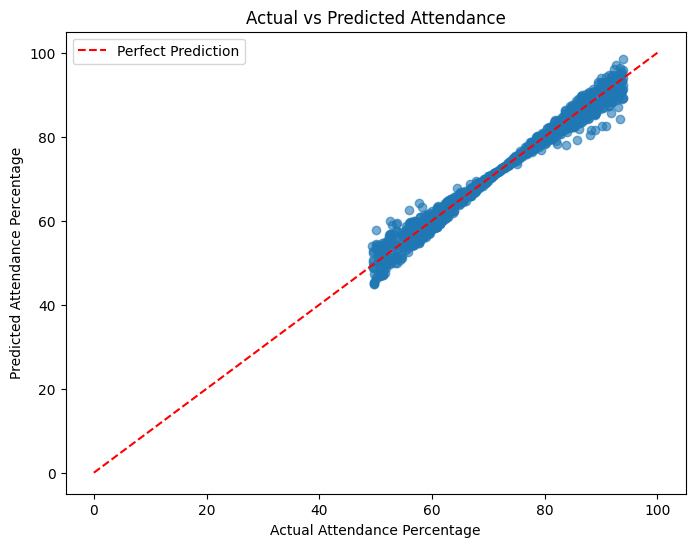

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Attendance Percentage")
plt.ylabel("Predicted Attendance Percentage")
plt.title("Actual vs Predicted Attendance")

# Perfect prediction line
plt.plot([0,100], [0,100], color='red', linestyle='--', label="Perfect Prediction")

plt.legend()
plt.show()


Why this is good?

If points lie near red line → model is good.

# **At-Risk vs Safe Students (Full Count Visualization)**

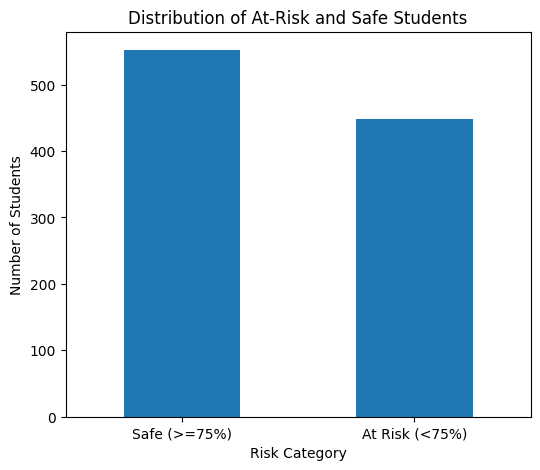

In [ ]:
plt.figure(figsize=(6,5))

risk_counts = results["At_Risk"].value_counts()

risk_counts.plot(kind="bar")

plt.xlabel("Risk Category")
plt.ylabel("Number of Students")
plt.title("Distribution of At-Risk and Safe Students")

plt.xticks([0,1], ["Safe (>=75%)", "At Risk (<75%)"], rotation=0)

plt.show()


# **Attendance Distribution (All 5000 Samples)**

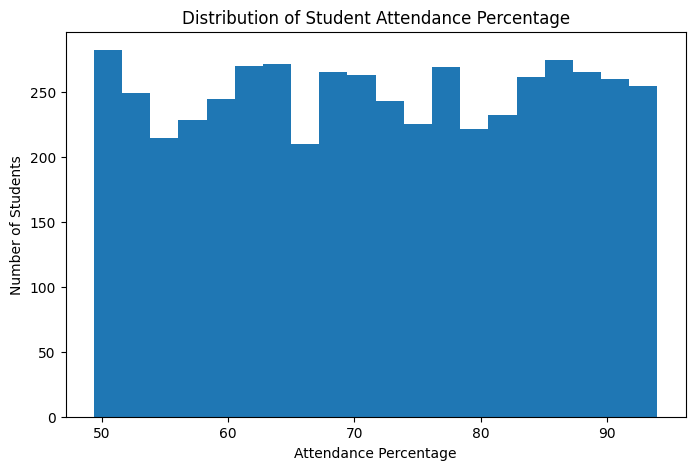

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["attendance_percentage"], bins=20)

plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Attendance Percentage")

plt.show()

# **Visualization using Scatter Plot for all Samples in the dataset**

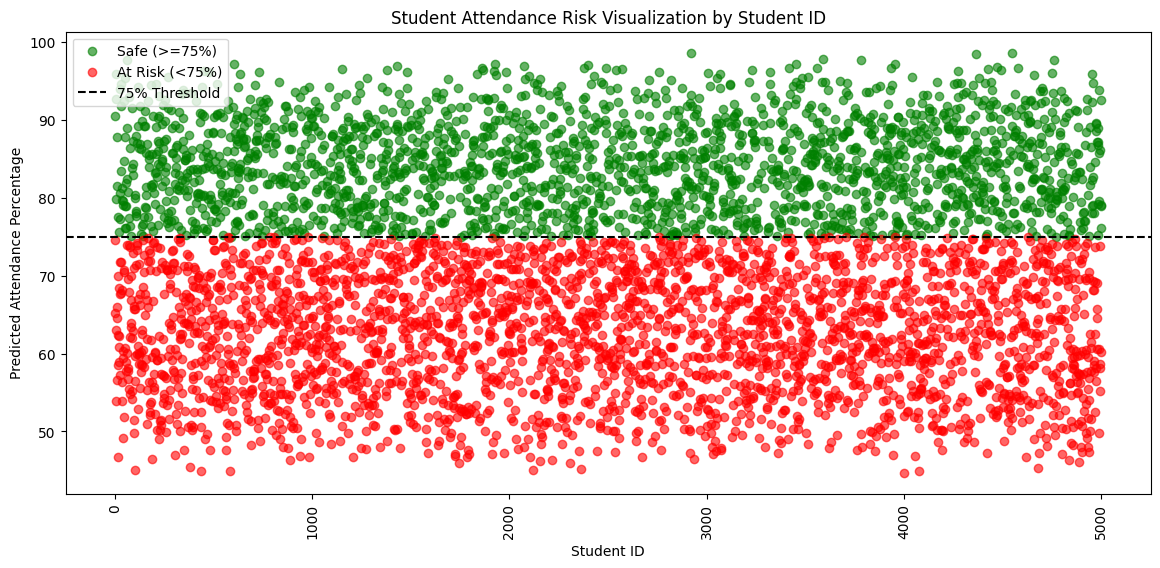

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Keep student_id separately
student_ids = df["student_id"]

# Scale full dataset
X_scaled_full = scaler.transform(X)

# Predict attendance
y_full_pred = model.predict(X_scaled_full)

# Create results dataframe including student_id
full_results = pd.DataFrame({
    "student_id": student_ids,
    "Predicted_Attendance": y_full_pred
})

# Risk condition
full_results["At_Risk"] = full_results["Predicted_Attendance"] < 75

# Plot
plt.figure(figsize=(14,6))

# Safe students (Green)
safe = full_results[full_results["At_Risk"] == False]
plt.scatter(safe["student_id"], safe["Predicted_Attendance"],
            color="green", label="Safe (>=75%)", alpha=0.6)

# At-risk students (Red)
risk = full_results[full_results["At_Risk"] == True]
plt.scatter(risk["student_id"], risk["Predicted_Attendance"],
            color="red", label="At Risk (<75%)", alpha=0.6)

# Threshold line
plt.axhline(y=75, color='black', linestyle='--', label="75% Threshold")

plt.xlabel("Student ID")
plt.ylabel("Predicted Attendance Percentage")
plt.title("Student Attendance Risk Visualization by Student ID")

plt.legend()
plt.xticks(rotation=90)  # rotate IDs if many students
plt.show()

# **Visualization using Scatter Plot for random 15 students**

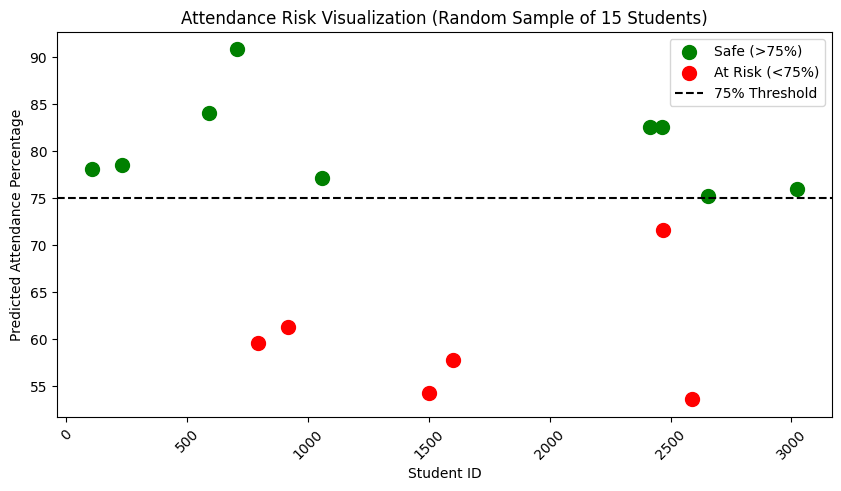

In [ ]:
# Randomly select 15 students
sample_data = full_results.sample(15, random_state=42)

plt.figure(figsize=(10,5))

safe = sample_data[sample_data["At_Risk"] == False]
risk = sample_data[sample_data["At_Risk"] == True]

plt.scatter(safe["student_id"], safe["Predicted_Attendance"],
            color="green", label="Safe (>75%)", s=100)

plt.scatter(risk["student_id"], risk["Predicted_Attendance"],
            color="red", label="At Risk (<75%)", s=100)

plt.axhline(y=75, color='black', linestyle='--', label="75% Threshold")

plt.xlabel("Student ID")
plt.ylabel("Predicted Attendance Percentage")
plt.title("Attendance Risk Visualization (Random Sample of 15 Students)")

plt.legend()
plt.xticks(rotation=45)
plt.show()

# **Visualization using Barchart**

**Bar charts are easier to read than scatter plots.**

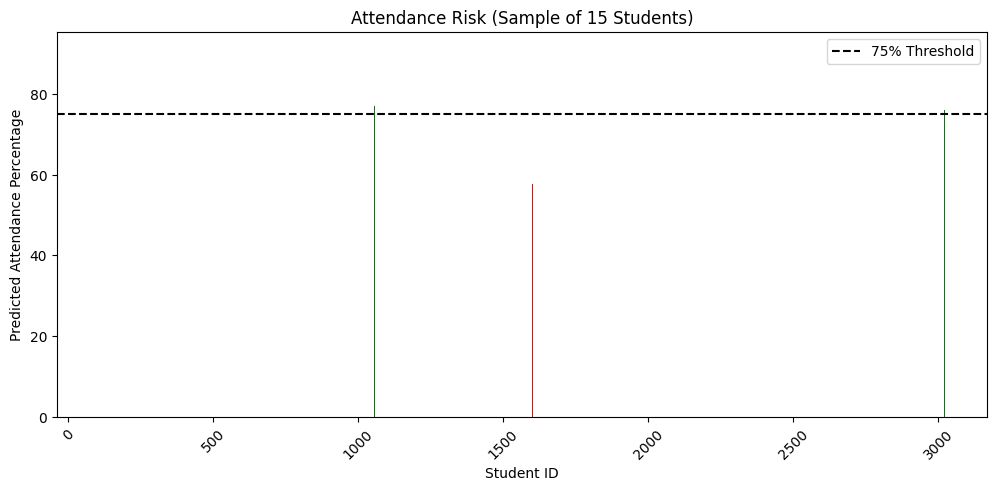

In [ ]:
plt.figure(figsize=(12,5))

colors = ["green" if x >= 75 else "red"
          for x in sample_data["Predicted_Attendance"]]

plt.bar(sample_data["student_id"],
        sample_data["Predicted_Attendance"],
        color=colors)

plt.axhline(y=75, color='black', linestyle='--', label="75% Threshold")

plt.xlabel("Student ID")
plt.ylabel("Predicted Attendance Percentage")
plt.title("Attendance Risk (Sample of 15 Students)")

plt.xticks(rotation=45)
plt.legend()
plt.show()

# **STUDENTS ATTENDANCE PERCENTAGE PREDICTION USING RANDOM FOREST**

This is actually more powerful than Linear Regression because:

✅ Handles non-linear relationships          
✅ Works well with complex datasets         
✅ Usually gives better accuracy

# **Step 1: Import Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor


# **Step 2: Create the Model**

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,        # Number of trees
    random_state=42
)

You can increase trees later (200, 300) for better accuracy.

# **Step 3: Train the Model**

In [ ]:
rf_model.fit(X_train_scaled, y_train)


RandomForestRegressor(random_state=42)

# **Step 4: Make Predictions (Test Data)**

In [ ]:
rf_pred = rf_model.predict(X_test_scaled)


# **Step 5: Evaluate the Model**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test, rf_pred)
mse_rf = mean_squared_error(y_test, rf_pred)
r2_rf = r2_score(y_test, rf_pred)

print("Random Forest Results:")
print("Mean Absolute Error:", mae_rf)
print("Mean Squared Error:", mse_rf)
print("R2 Score:", r2_rf)


Random Forest Results:
Mean Absolute Error: 0.3163196999999991
Mean Squared Error: 0.36786403108999716
R2 Score: 0.9977937223952942


# **Step 6: Compare with Linear Regression**

In [ ]:
print("Linear Regression R2:", r2)
print("Random Forest R2:", r2_rf)


Linear Regression R2: 0.9779386452338081
Random Forest R2: 0.9977937223952942


Usually Random Forest gives higher R2.

# **Step 7: Predict For All Students**

In [ ]:
X_scaled_full = scaler.transform(X)
rf_full_pred = rf_model.predict(X_scaled_full)

rf_results = pd.DataFrame({
    "Student_ID": df["student_id"],
    "Predicted_Attendance": rf_full_pred
})

rf_results["At_Risk"] = rf_results["Predicted_Attendance"] < 75

# **Step 8: Visualize Sample (15 Students)**

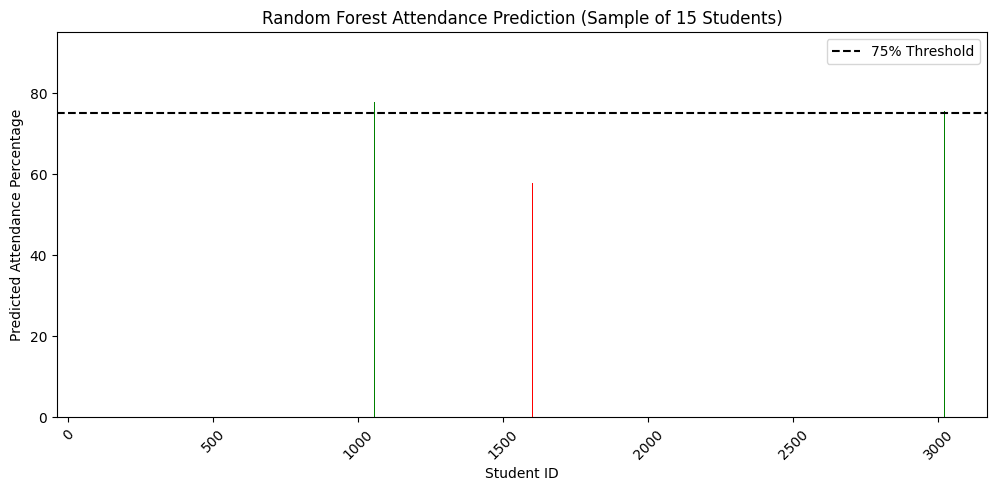

In [ ]:
sample_rf = rf_results.sample(15, random_state=42)

plt.figure(figsize=(12,5))

colors = ["green" if x >= 75 else "red"
          for x in sample_rf["Predicted_Attendance"]]

plt.bar(sample_rf["Student_ID"],
        sample_rf["Predicted_Attendance"],
        color=colors)

plt.axhline(y=75, color='black', linestyle='--', label="75% Threshold")

plt.xlabel("Student ID")
plt.ylabel("Predicted Attendance Percentage")
plt.title("Random Forest Attendance Prediction (Sample of 15 Students)")

plt.xticks(rotation=45)
plt.legend()
plt.show()


# **BONUS: Feature Importance**

Random Forest gives feature importance automatically.

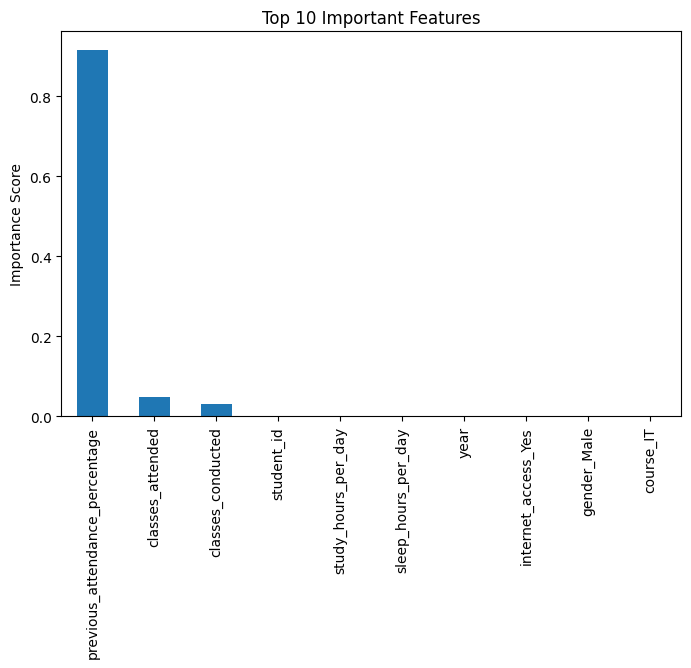

In [ ]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.show()


Random Forest is an ensemble learning method that builds multiple decision trees and averages their predictions.
It handles non-linear relationships better than Linear Regression and generally improves accuracy.

In [ ]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from google.colab import files
files.download("model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>